# P2 — Human Mobility Intelligence Indonesia
## Exploratory Data Analysis

**Project:** Spatial Economic Intelligence Indonesia  
**Author:** mikoo97  
**Last updated:** Mei 2026

> *Ke mana orang Indonesia bergerak, dan bagaimana COVID-19 mengubah pola tersebut?*

In [14]:
# ============================================================
# CELL 1 — SETUP & IMPORT
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
import os
import glob

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Path — notebook ada di /notebooks/, data ada di /data/processed/
DATA_DIR   = '../data/processed/'
OUTPUT_DIR = '../outputs/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Color palette
C = {
    'primary': '#2C3E50',
    'blue':    '#3498DB',
    'red':     '#E74C3C',
    'green':   '#27AE60',
    'orange':  '#F39C12',
    'grey':    '#95A5A6',
}

print('✅ Setup selesai')
print(f'   Pandas  : {pd.__version__}')
print(f'   NumPy   : {np.__version__}')
print(f'   Data dir: {os.path.abspath(DATA_DIR)}')

✅ Setup selesai
   Pandas  : 3.0.3
   NumPy   : 2.4.4
   Data dir: D:\Project\human-mobility-id\data\processed


In [15]:
# ============================================================
# CELL 2 — LOAD SEMUA DATASET
# ============================================================
df_sp2020   = pd.read_csv(DATA_DIR + 'bps_migrasi_risen_provinsi_sp2020.csv')
df_2019     = pd.read_csv(DATA_DIR + 'bps_migran_risen_2019_susenas.csv')
df_sakernas = pd.read_csv(DATA_DIR + 'bps_pekerja_migran_sakernas_2021_2022.csv')
df_2324     = pd.read_csv(DATA_DIR + 'bps_migrasi_risen_persen_2023_2024.csv')
df_sus2024  = pd.read_csv(DATA_DIR + 'bps_migrasi_risen_persen_provinsi_2024.csv')
df_komuter  = pd.read_csv(DATA_DIR + 'bps_komuter_provinsi_2024.csv')
df_meta_kab = pd.read_csv(DATA_DIR + 'meta_mobility_agregat_kabupaten.csv')
df_meta_bln = pd.read_csv(DATA_DIR + 'meta_mobility_tren_bulanan.csv')

print('✅ Semua dataset berhasil diload!\n')
datasets = {
    'SP2020 Migrasi Risen' : df_sp2020,
    'SUSENAS 2019'         : df_2019,
    'SAKERNAS 2021-2022'   : df_sakernas,
    'SUSENAS 2023-2024'    : df_2324,
    'SUSENAS 2024 (%)'     : df_sus2024,
    'Komuter 2024'         : df_komuter,
    'Meta Kabupaten'       : df_meta_kab,
    'Meta Tren Bulanan'    : df_meta_bln,
}
for name, df in datasets.items():
    print(f'  {name:30s}: {df.shape[0]:>4} baris x {df.shape[1]:>2} kolom')

✅ Semua dataset berhasil diload!

  SP2020 Migrasi Risen          :   34 baris x  6 kolom
  SUSENAS 2019                  :   33 baris x  5 kolom
  SAKERNAS 2021-2022            :   68 baris x  4 kolom
  SUSENAS 2023-2024             :   73 baris x  6 kolom
  SUSENAS 2024 (%)              :   38 baris x  6 kolom
  Komuter 2024                  :   32 baris x  5 kolom
  Meta Kabupaten                :  956 baris x  7 kolom
  Meta Tren Bulanan             :   17 baris x  4 kolom


In [16]:
# ============================================================
# CELL 3 — INSPEKSI KOLOM SEMUA DATASET
# ============================================================
for name, df in datasets.items():
    print(f'\n[{name}]')
    for i, col in enumerate(df.columns):
        print(f'  [{i}] {col} — {df[col].dtype}')


[SP2020 Migrasi Risen]
  [0] provinsi — str
  [1] migrasi_masuk — int64
  [2] migrasi_keluar — int64
  [3] migrasi_neto — int64
  [4] pulau — str
  [5] status_migrasi — str

[SUSENAS 2019]
  [0] provinsi — str
  [1] migran_masuk_absolut — int64
  [2] pct_migran_masuk — float64
  [3] tahun — int64
  [4] sumber — str

[SAKERNAS 2021-2022]
  [0] provinsi — str
  [1] tahun — int64
  [2] pct_pekerja_migran_risen — float64
  [3] sumber — str

[SUSENAS 2023-2024]
  [0] provinsi — str
  [1] pct_migran_masuk_risen — float64
  [2] pct_migran_keluar_risen — float64
  [3] tahun — int64
  [4] neto_pct — float64
  [5] sumber — str

[SUSENAS 2024 (%)]
  [0] provinsi — str
  [1] pct_migran_masuk_risen — float64
  [2] pct_migran_keluar_risen — float64
  [3] neto_pct — float64
  [4] tahun — int64
  [5] sumber — str

[Komuter 2024]
  [0] provinsi — str
  [1] komuter_perdesaan_total — int64
  [2] pct_perdesaan — float64
  [3] tahun — int64
  [4] sumber — str

[Meta Kabupaten]
  [0] polygon_name — str
  [

In [17]:
# ============================================================
# CELL 4 — SET NAMA KOLOM SP2020
# Sesuaikan setelah lihat output Cell 3
# ============================================================
def find_col(df, keywords):
    for kw in keywords:
        matches = [c for c in df.columns if kw.lower() in c.lower()]
        if matches:
            return matches[0]
    return None

COL_PROV   = find_col(df_sp2020, ['provinsi', 'province', 'wilayah', 'nama'])
COL_MASUK  = find_col(df_sp2020, ['masuk', 'in', 'datang', 'tujuan'])
COL_KELUAR = find_col(df_sp2020, ['keluar', 'out', 'pergi', 'asal'])
COL_NETO   = find_col(df_sp2020, ['neto', 'net', 'bersih', 'selisih'])

print(f'Kolom provinsi : {COL_PROV}')
print(f'Kolom masuk    : {COL_MASUK}')
print(f'Kolom keluar   : {COL_KELUAR}')
print(f'Kolom neto     : {COL_NETO}')
print()

# === KALAU ADA YANG None, ISI MANUAL DI SINI ===
# COL_PROV   = 'nama_kolom'
# COL_MASUK  = 'nama_kolom'
# COL_KELUAR = 'nama_kolom'
# COL_NETO   = 'nama_kolom'

assert COL_PROV   is not None, 'COL_PROV tidak ditemukan — isi manual'
assert COL_MASUK  is not None, 'COL_MASUK tidak ditemukan — isi manual'
assert COL_KELUAR is not None, 'COL_KELUAR tidak ditemukan — isi manual'
assert COL_NETO   is not None, 'COL_NETO tidak ditemukan — isi manual'

print('✅ Semua kolom SP2020 terdeteksi')

Kolom provinsi : provinsi
Kolom masuk    : migrasi_masuk
Kolom keluar   : migrasi_keluar
Kolom neto     : migrasi_neto

✅ Semua kolom SP2020 terdeteksi


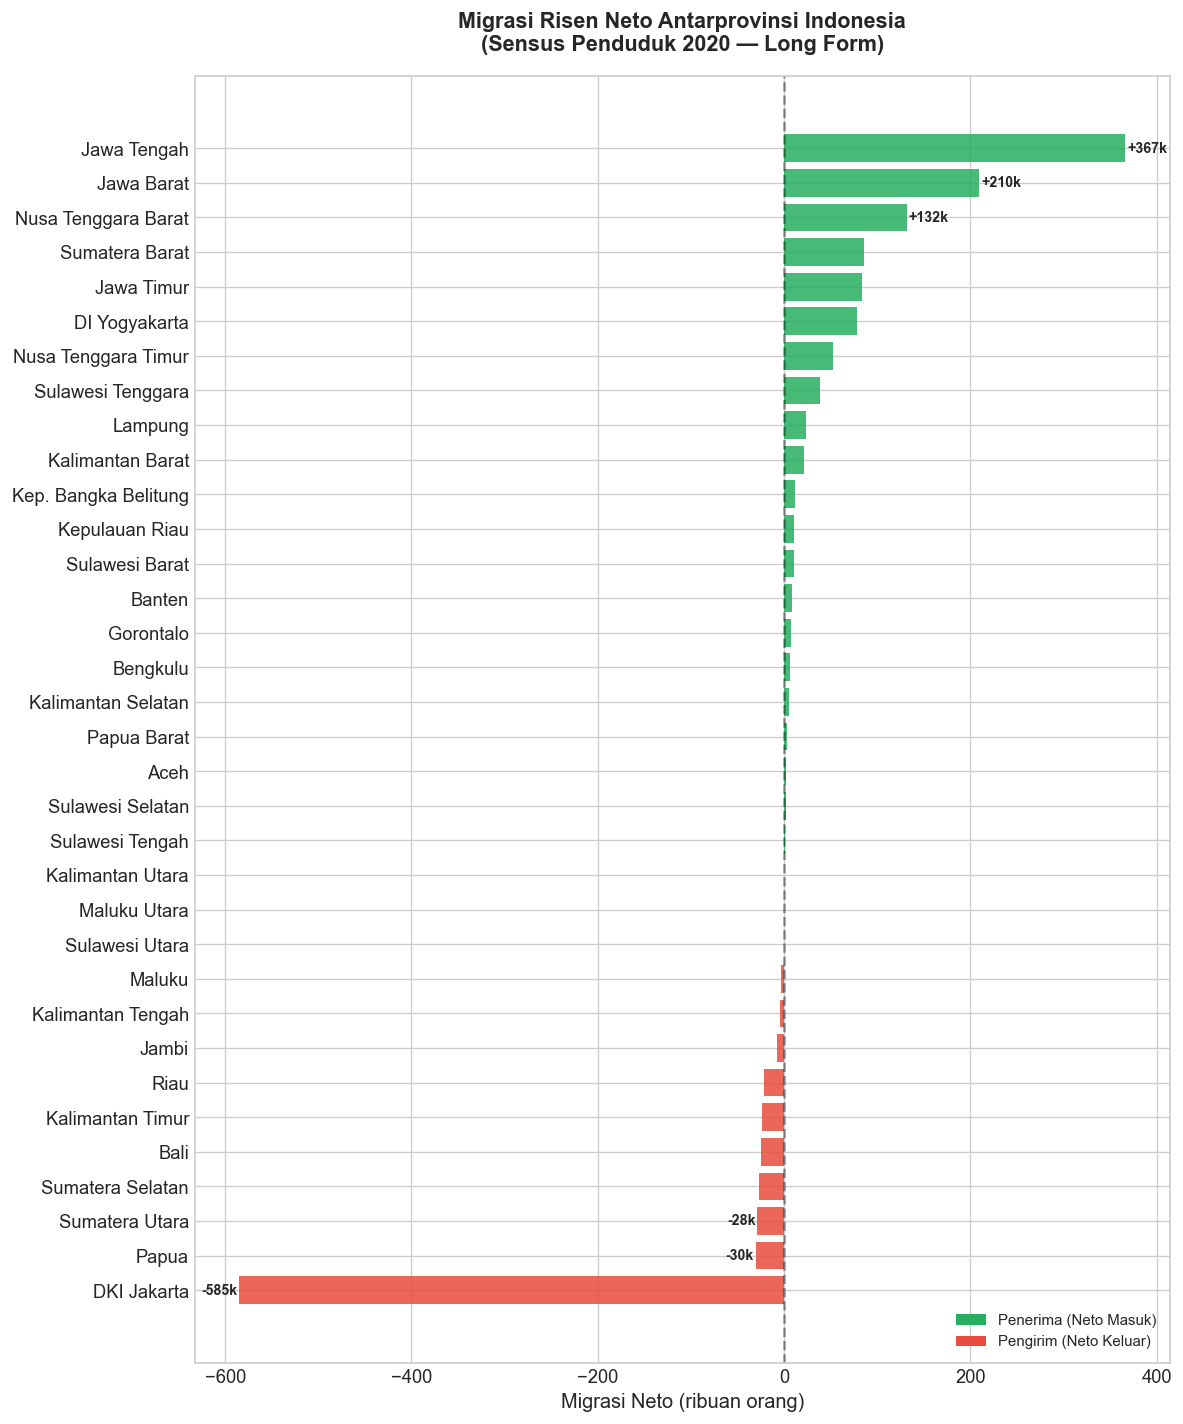

✓ Chart tersimpan


In [18]:
# ============================================================
# CELL 5 — CHART 1: MIGRASI NETO PER PROVINSI (SP2020)
# ============================================================
df = df_sp2020.copy().sort_values(COL_NETO, ascending=True)
colors = [C['green'] if v >= 0 else C['red'] for v in df[COL_NETO]]

fig, ax = plt.subplots(figsize=(10, 12))
ax.barh(df[COL_PROV], df[COL_NETO] / 1000, color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=1.5, ls='--', alpha=0.4)

for idx in list(range(3)) + list(range(len(df)-3, len(df))):
    row = df.iloc[idx]
    val = row[COL_NETO] / 1000
    ax.text(val + (2 if val >= 0 else -2), idx,
            f'{val:+.0f}k', va='center',
            ha='left' if val >= 0 else 'right',
            fontsize=8.5, fontweight='bold')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=C['green'], label='Penerima (Neto Masuk)'),
    Patch(facecolor=C['red'],   label='Pengirim (Neto Keluar)')
], loc='lower right', fontsize=9)

ax.set_xlabel('Migrasi Neto (ribuan orang)', fontsize=12)
ax.set_title('Migrasi Risen Neto Antarprovinsi Indonesia\n(Sensus Penduduk 2020 — Long Form)',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
fig.savefig(OUTPUT_DIR + 'p2_01_migrasi_neto_sp2020.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Chart tersimpan')

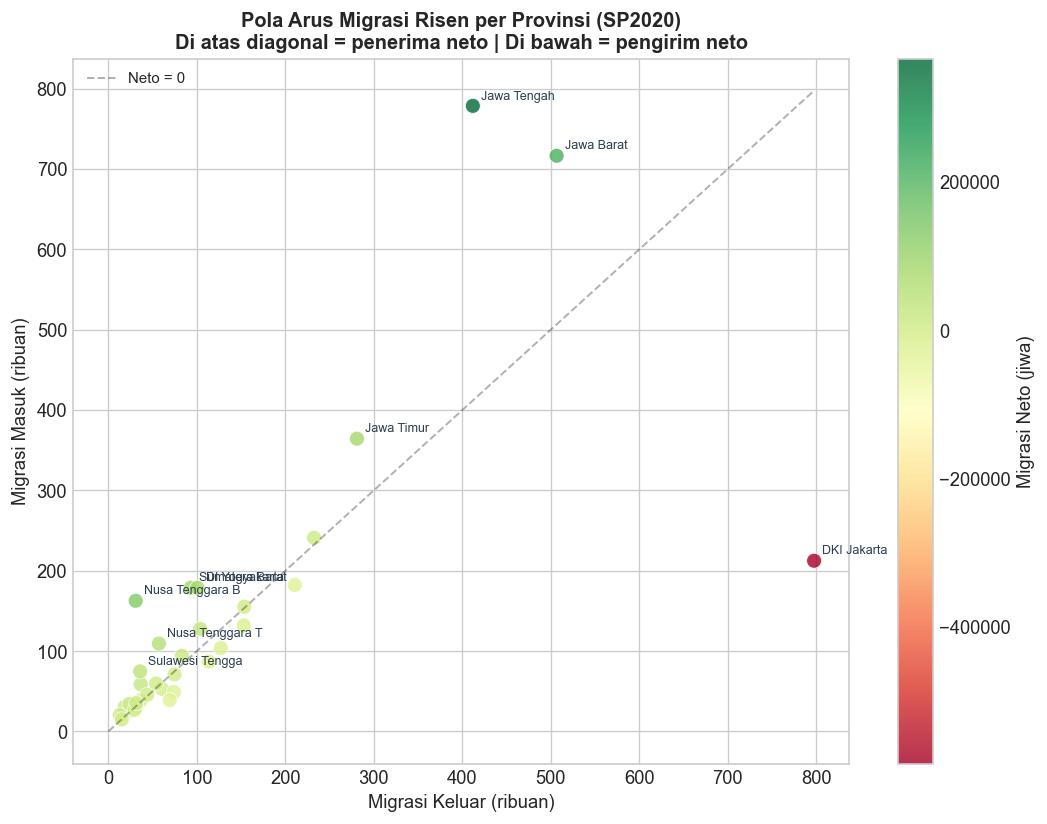

✓ Chart tersimpan


In [19]:
# ============================================================
# CELL 6 — CHART 2: SCATTER MASUK vs KELUAR
# ============================================================
fig, ax = plt.subplots(figsize=(9, 7))

sc = ax.scatter(
    df_sp2020[COL_KELUAR] / 1000,
    df_sp2020[COL_MASUK]  / 1000,
    c=df_sp2020[COL_NETO], cmap='RdYlGn',
    s=80, alpha=0.8, edgecolors='white', lw=0.5
)
max_val = max(df_sp2020[COL_MASUK].max(), df_sp2020[COL_KELUAR].max()) / 1000
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, lw=1.2, label='Neto = 0')

threshold = df_sp2020[COL_NETO].abs().quantile(0.75)
for _, row in df_sp2020[df_sp2020[COL_NETO].abs() > threshold].iterrows():
    ax.annotate(str(row[COL_PROV])[:15],
                xy=(row[COL_KELUAR]/1000, row[COL_MASUK]/1000),
                xytext=(5, 4), textcoords='offset points',
                fontsize=7.5, color=C['primary'])

plt.colorbar(sc, ax=ax, label='Migrasi Neto (jiwa)')
ax.set_xlabel('Migrasi Keluar (ribuan)', fontsize=11)
ax.set_ylabel('Migrasi Masuk (ribuan)', fontsize=11)
ax.set_title('Pola Arus Migrasi Risen per Provinsi (SP2020)\n'
             'Di atas diagonal = penerima neto | Di bawah = pengirim neto',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(OUTPUT_DIR + 'p2_02_scatter_masuk_keluar.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Chart tersimpan')

Kolom tanggal : bulan
Kolom nilai   : tahun


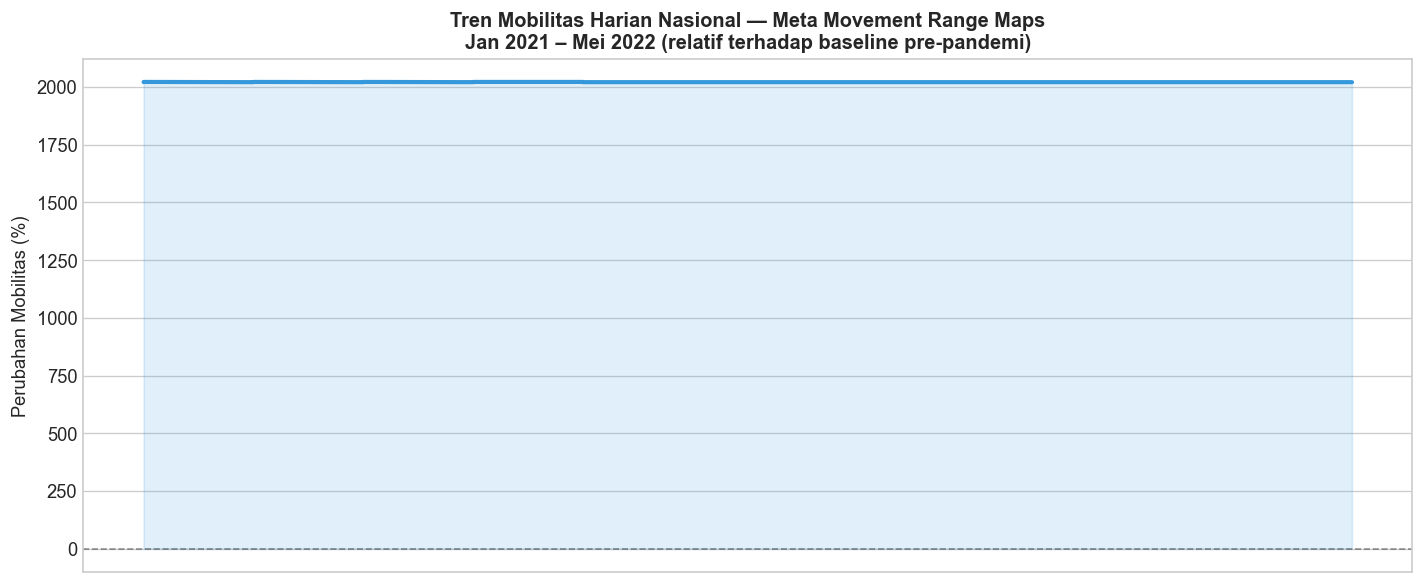

✓ Chart tersimpan


In [20]:
# ============================================================
# CELL 7 — CHART 3: TREN MOBILITAS BULANAN (META)
# ============================================================
df_ts = df_meta_bln.copy()

col_date = [c for c in df_ts.columns
            if any(k in c.lower() for k in ['date','bulan','tanggal','month','ds'])]
col_date = col_date[0] if col_date else df_ts.columns[0]
col_val  = df_ts.select_dtypes(include='number').columns[0]

print(f'Kolom tanggal : {col_date}')
print(f'Kolom nilai   : {col_val}')

df_ts[col_date] = pd.to_datetime(df_ts[col_date])
df_ts = df_ts.sort_values(col_date)

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(df_ts[col_date], df_ts[col_val], alpha=0.15, color=C['blue'])
ax.plot(df_ts[col_date], df_ts[col_val], color=C['blue'], lw=2.5)
ax.axhline(0, color='black', lw=1, ls='--', alpha=0.4)

events = [
    ('2021-07-01', 'PPKM Darurat\n(Delta)', -12),
    ('2021-10-01', 'Recovery\nOkt 2021', 3),
    ('2022-02-01', 'Gelombang\nOmicron', -22),
]
for date_str, label, y_off in events:
    ed = pd.to_datetime(date_str)
    closest = df_ts.iloc[(df_ts[col_date]-ed).abs().argsort()[:1]]
    if len(closest):
        yv = closest[col_val].values[0]
        ax.annotate(label, xy=(ed, yv), xytext=(ed, yv+y_off),
                    fontsize=8, ha='center', color=C['red'],
                    arrowprops=dict(arrowstyle='->', color=C['red'], lw=1.2))

ax.set_ylabel('Perubahan Mobilitas (%)', fontsize=11)
ax.set_title('Tren Mobilitas Harian Nasional — Meta Movement Range Maps\n'
             'Jan 2021 – Mei 2022 (relatif terhadap baseline pre-pandemi)',
             fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
fig.savefig(OUTPUT_DIR + 'p2_03_meta_tren_nasional.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Chart tersimpan')

In [21]:
# ============================================================
# CELL 8 — SET KOLOM META KABUPATEN
# ============================================================
print('Kolom meta_kab:')
for i, col in enumerate(df_meta_kab.columns):
    print(f'  [{i}] {col} — {df_meta_kab[col].dtype}')
print()
display(df_meta_kab.head(3))

col_kab = [c for c in df_meta_kab.columns
           if any(k in c.lower() for k in ['kabupaten','kota','name','nama','region','district'])]
col_kab = col_kab[0] if col_kab else df_meta_kab.columns[0]

col_mob = df_meta_kab.select_dtypes(include='number').columns[0]

print(f'\nKolom kabupaten : {col_kab}')
print(f'Kolom mobilitas : {col_mob}')

Kolom meta_kab:
  [0] polygon_name — str
  [1] tahun — int64
  [2] movement_change_mean — float64
  [3] movement_change_min — float64
  [4] movement_change_max — float64
  [5] stay_put_mean — float64
  [6] n_records — int64



,polygon_name,tahun,movement_change_mean,movement_change_min,movement_change_max,stay_put_mean,n_records
0,Aceh Barat,2021,0.004487,-0.28620,0.33305,0.184570,365
1,Aceh Barat,2022,-0.121384,-0.36372,0.14992,0.240895,142
2,Aceh Barat Daya,2021,-0.012144,-0.25276,0.50708,0.190569,365



Kolom kabupaten : polygon_name
Kolom mobilitas : tahun


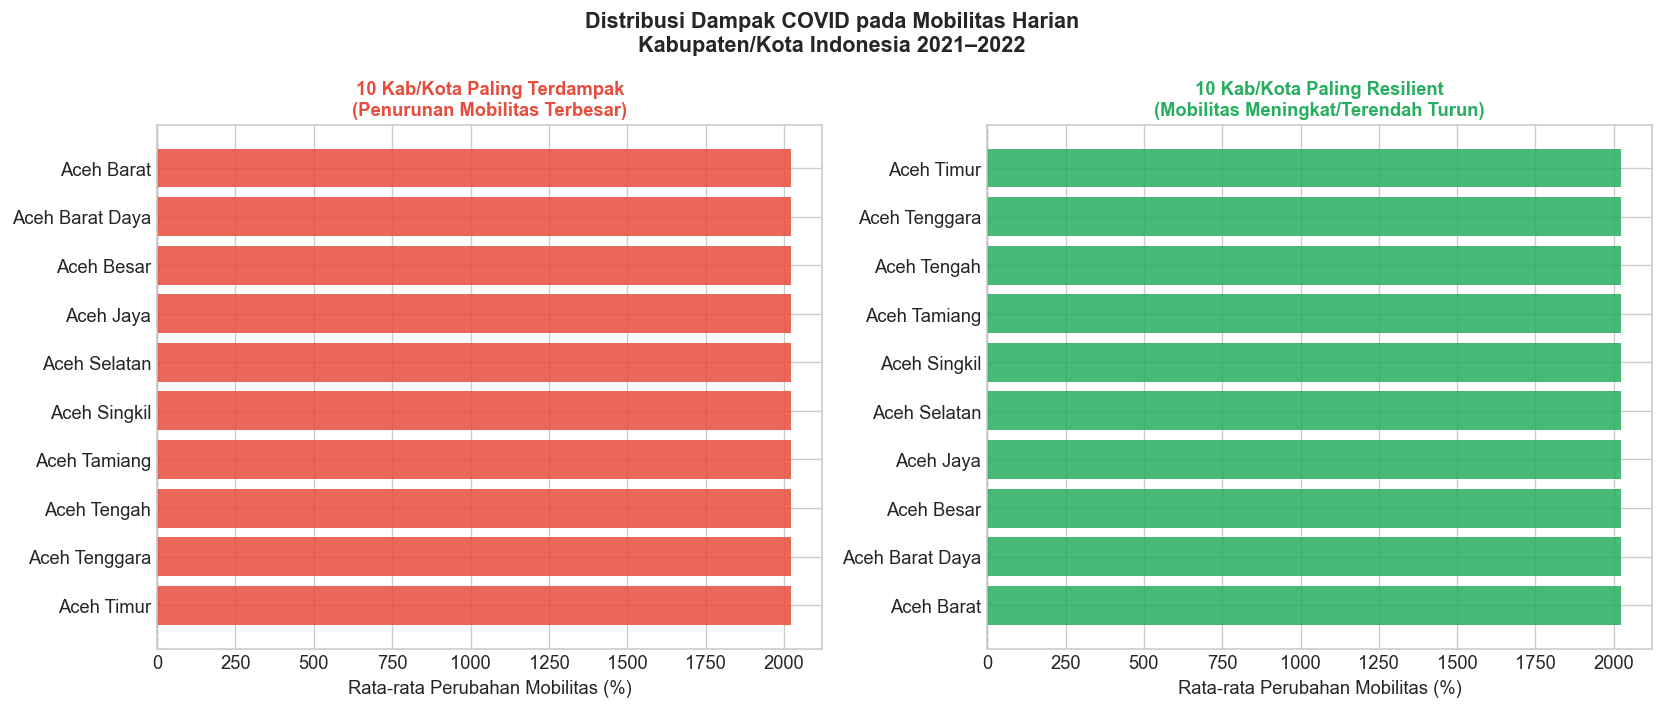

✓ Chart tersimpan


In [22]:
# ============================================================
# CELL 9 — CHART 4: TOP/BOTTOM KABUPATEN MOBILITAS
# ============================================================
top10    = df_meta_kab.nlargest(10, col_mob)
bottom10 = df_meta_kab.nsmallest(10, col_mob)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.barh(bottom10[col_kab][::-1], bottom10[col_mob][::-1], color=C['red'], alpha=0.85)
ax1.set_title('10 Kab/Kota Paling Terdampak\n(Penurunan Mobilitas Terbesar)',
              fontsize=11, fontweight='bold', color=C['red'])
ax1.set_xlabel('Rata-rata Perubahan Mobilitas (%)')
ax1.axvline(0, color='black', lw=0.8, ls='--', alpha=0.4)

ax2.barh(top10[col_kab], top10[col_mob], color=C['green'], alpha=0.85)
ax2.set_title('10 Kab/Kota Paling Resilient\n(Mobilitas Meningkat/Terendah Turun)',
              fontsize=11, fontweight='bold', color=C['green'])
ax2.set_xlabel('Rata-rata Perubahan Mobilitas (%)')
ax2.axvline(0, color='black', lw=0.8, ls='--', alpha=0.4)

fig.suptitle('Distribusi Dampak COVID pada Mobilitas Harian\nKabupaten/Kota Indonesia 2021–2022',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(OUTPUT_DIR + 'p2_04_meta_top_bottom_kab.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Chart tersimpan')

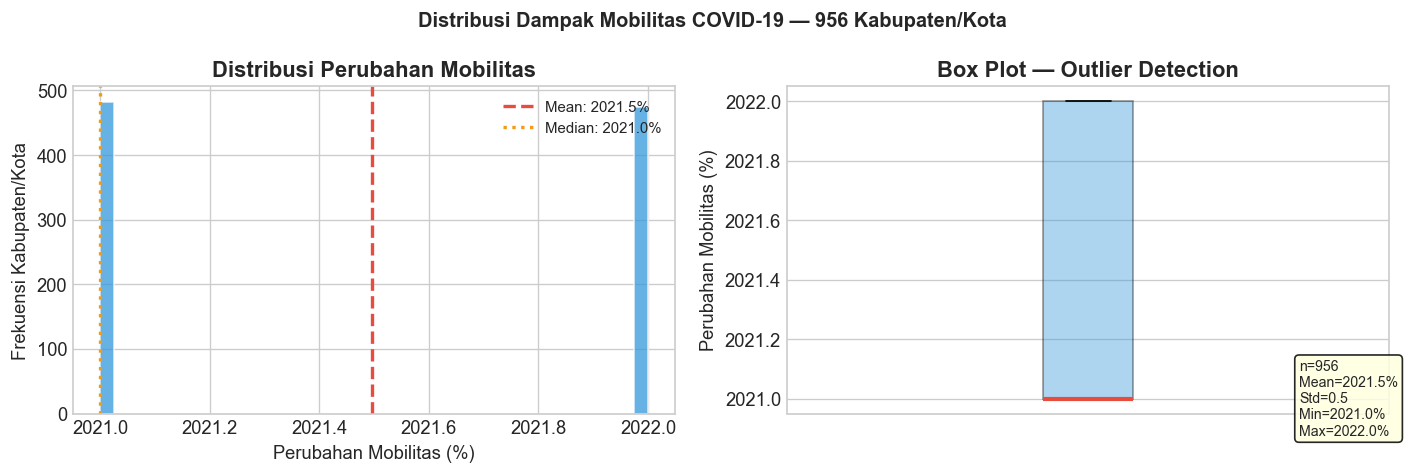

✓ Chart tersimpan


In [23]:
# ============================================================
# CELL 10 — CHART 5: DISTRIBUSI MOBILITAS
# ============================================================
data = df_meta_kab[col_mob].dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(data, bins=40, color=C['blue'], alpha=0.75, edgecolor='white')
ax1.axvline(data.mean(),   color=C['red'],    lw=2, ls='--', label=f'Mean: {data.mean():.1f}%')
ax1.axvline(data.median(), color=C['orange'], lw=2, ls=':',  label=f'Median: {data.median():.1f}%')
ax1.legend(fontsize=9)
ax1.set_title('Distribusi Perubahan Mobilitas', fontweight='bold')
ax1.set_xlabel('Perubahan Mobilitas (%)')
ax1.set_ylabel('Frekuensi Kabupaten/Kota')

ax2.boxplot(data, vert=True, patch_artist=True,
            boxprops=dict(facecolor=C['blue'], alpha=0.4),
            medianprops=dict(color=C['red'], lw=2.5))
ax2.set_title('Box Plot — Outlier Detection', fontweight='bold')
ax2.set_ylabel('Perubahan Mobilitas (%)')
ax2.set_xticks([])
ax2.text(1.35, data.median(),
         f'n={data.count()}\nMean={data.mean():.1f}%\nStd={data.std():.1f}\nMin={data.min():.1f}%\nMax={data.max():.1f}%',
         fontsize=8.5, va='center',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85))

fig.suptitle(f'Distribusi Dampak Mobilitas COVID-19 — {len(df_meta_kab)} Kabupaten/Kota',
             fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig(OUTPUT_DIR + 'p2_05_distribusi_mobilitas.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Chart tersimpan')

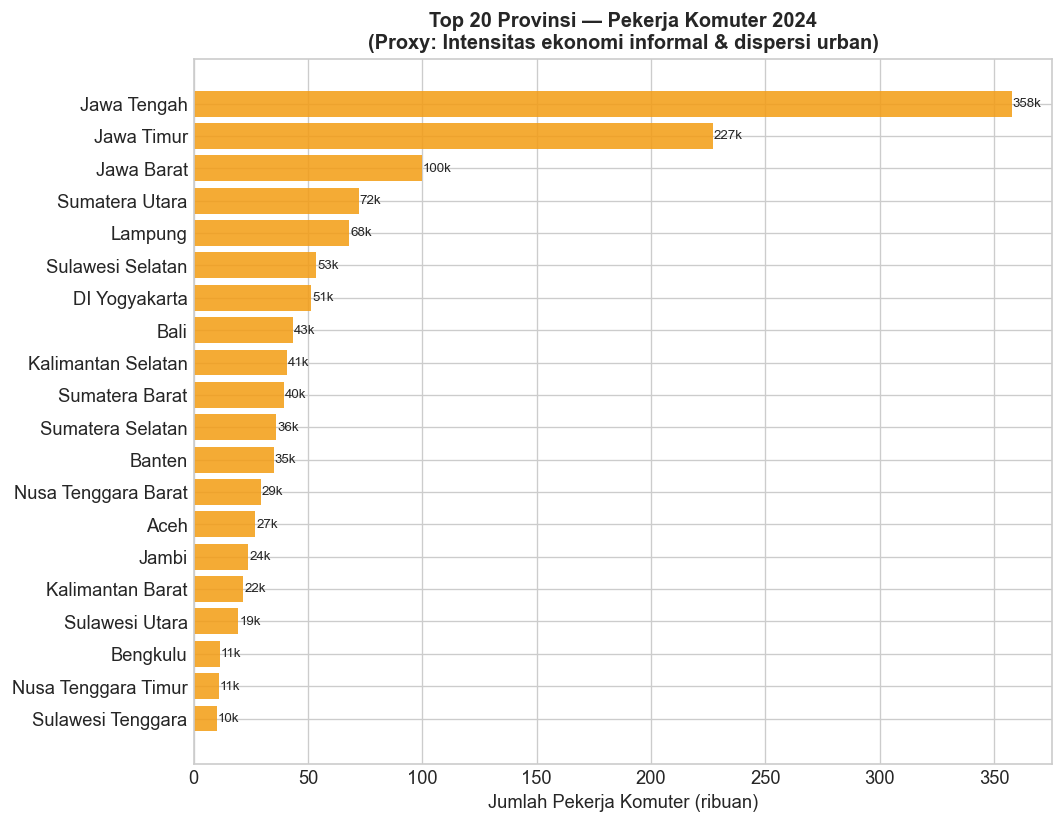

✓ Chart tersimpan


In [24]:
# ============================================================
# CELL 11 — CHART 6: KOMUTER PER PROVINSI
# ============================================================
df_k = df_komuter.copy()
col_prov_k = [c for c in df_k.columns
              if any(k in c.lower() for k in ['provinsi','province','wilayah','nama'])]
col_prov_k = col_prov_k[0] if col_prov_k else df_k.columns[0]
col_kom    = df_k.select_dtypes(include='number').columns[0]

df_k = df_k.sort_values(col_kom, ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(df_k[col_prov_k][::-1], df_k[col_kom][::-1] / 1000,
               color=C['orange'], alpha=0.85)
for bar, val in zip(bars, df_k[col_kom][::-1] / 1000):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}k', va='center', fontsize=8)

ax.set_xlabel('Jumlah Pekerja Komuter (ribuan)', fontsize=11)
ax.set_title('Top 20 Provinsi — Pekerja Komuter 2024\n'
             '(Proxy: Intensitas ekonomi informal & dispersi urban)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig(OUTPUT_DIR + 'p2_06_komuter_provinsi.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Chart tersimpan')

Data tren:
   tahun           rata
0   2019  162775.484848
1   2023       0.990278
2   2024       1.053521


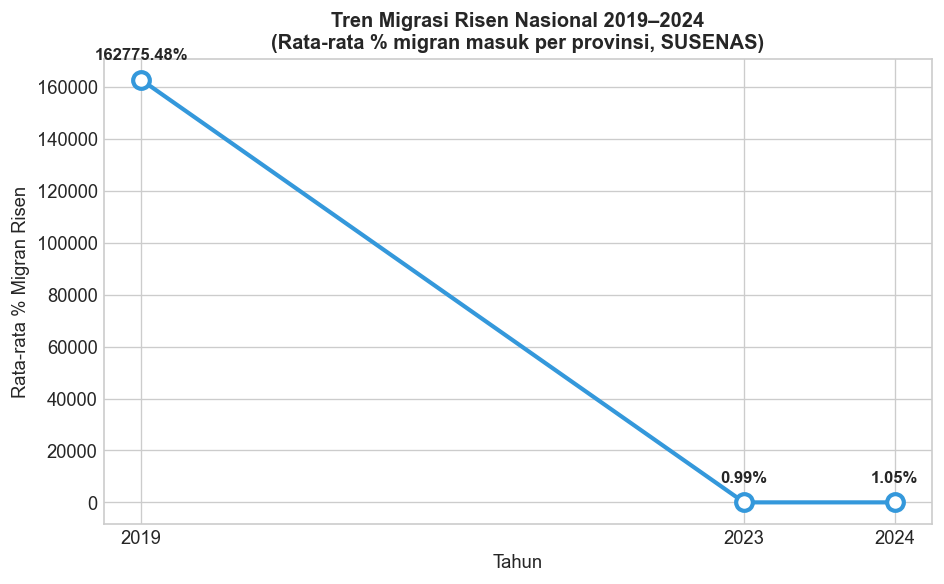

✓ Chart tersimpan


In [25]:
# ============================================================
# CELL 12 — CHART 7: TREN MIGRASI 2019–2024
# ============================================================
num_2019 = df_2019.select_dtypes(include='number')
num_2324 = df_2324.select_dtypes(include='number')

rata_2019 = num_2019.iloc[:, 0].mean() if len(num_2019.columns) > 0 else np.nan
rata_2023 = num_2324.iloc[:, 0].mean() if len(num_2324.columns) > 0 else np.nan
rata_2024 = num_2324.iloc[:, 1].mean() if len(num_2324.columns) > 1 else np.nan

tren = pd.DataFrame({
    'tahun': [2019, 2023, 2024],
    'rata': [rata_2019, rata_2023, rata_2024]
}).dropna()

print('Data tren:')
print(tren)

if len(tren) >= 2:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(tren['tahun'], tren['rata'], 'o-', color=C['blue'],
            lw=2.5, ms=10, markerfacecolor='white', markeredgewidth=2.5)
    for _, row in tren.iterrows():
        ax.annotate(f"{row['rata']:.2f}%",
                    xy=(row['tahun'], row['rata']),
                    xytext=(0, 12), textcoords='offset points',
                    ha='center', fontsize=10, fontweight='bold')
    ax.set_xticks(tren['tahun'].tolist())
    ax.set_xlabel('Tahun', fontsize=11)
    ax.set_ylabel('Rata-rata % Migran Risen', fontsize=11)
    ax.set_title('Tren Migrasi Risen Nasional 2019–2024\n'
                 '(Rata-rata % migran masuk per provinsi, SUSENAS)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR + 'p2_07_tren_migrasi_2019_2024.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✓ Chart tersimpan')
else:
    print('⚠️ Data tren tidak cukup — cek kolom numerik df_2019 dan df_2324')

In [26]:
# ============================================================
# CELL 13 — AGREGASI META KAB → PROVINSI
# ============================================================
col_prov_m = [c for c in df_meta_kab.columns
              if any(k in c.lower() for k in ['provinsi','province','prov'])]

if col_prov_m:
    col_prov_m = col_prov_m[0]
    df_meta_prov = (df_meta_kab
                   .groupby(col_prov_m)[col_mob]
                   .agg(['mean','median','std'])
                   .reset_index()
                   .rename(columns={col_prov_m: 'provinsi',
                                    'mean': 'meta_mean',
                                    'median': 'meta_median',
                                    'std': 'meta_std'}))
    print(f'✅ Agregasi berhasil: {len(df_meta_prov)} provinsi')
    display(df_meta_prov.head())
else:
    print('⚠️ Tidak ada kolom provinsi di meta_kab')
    print('  Kolom tersedia:', df_meta_kab.columns.tolist())
    df_meta_prov = None

⚠️ Tidak ada kolom provinsi di meta_kab
  Kolom tersedia: ['polygon_name', 'tahun', 'movement_change_mean', 'movement_change_min', 'movement_change_max', 'stay_put_mean', 'n_records']


In [27]:
# ============================================================
# CELL 14 — JOIN SP2020 + META PROVINSI
# ============================================================
if df_meta_prov is not None:
    def norm(s):
        return (str(s).upper()
                .replace('PROVINSI ', '').replace('DI ', '')
                .replace('KEP.', 'KEPULAUAN').strip())

    df_sp2020['key'] = df_sp2020[COL_PROV].apply(norm)
    df_meta_prov['key'] = df_meta_prov['provinsi'].apply(norm)

    df_join = df_sp2020.merge(df_meta_prov, on='key', how='inner')
    print(f'✅ Join berhasil: {len(df_join)} provinsi ter-match')

    unmatched = set(df_sp2020['key']) - set(df_join['key'])
    if unmatched:
        print(f'  Tidak match: {sorted(unmatched)}')

    display(df_join[[COL_PROV, COL_NETO, 'meta_mean']].head(10))
else:
    print('Skip — meta_prov tidak tersedia')
    df_join = None

Skip — meta_prov tidak tersedia


In [28]:
# ============================================================
# CELL 15 — CHART 8: KORELASI MIGRASI vs MOBILITAS
# ============================================================
if df_join is not None and len(df_join) >= 5:
    x = df_join[COL_NETO] / 1000
    y = df_join['meta_mean']
    slope, intercept, r, p, se = stats.linregress(x, y)

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.scatter(x, y, s=80, alpha=0.75, color=C['blue'],
               edgecolors='white', lw=0.5, zorder=3)

    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, slope*x_line + intercept, color=C['red'], lw=2, ls='--',
            label=f'r² = {r**2:.3f}  |  p = {p:.4f}')

    for _, row in df_join.iterrows():
        ax.annotate(str(row[COL_PROV])[:12],
                    xy=(row[COL_NETO]/1000, row['meta_mean']),
                    xytext=(3, 3), textcoords='offset points',
                    fontsize=6.5, alpha=0.8)

    ax.axhline(0, color='grey', lw=0.8, ls=':', alpha=0.5)
    ax.axvline(0, color='grey', lw=0.8, ls=':', alpha=0.5)
    ax.legend(fontsize=10)

    sig = '✅ Signifikan' if p < 0.05 else '⚠️ Tidak signifikan'
    ax.text(0.02, 0.02, f'{sig} (p={p:.4f})\nPearson r = {r:.3f}',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85))

    ax.set_xlabel('Migrasi Neto SP2020 (ribuan jiwa)', fontsize=11)
    ax.set_ylabel('Rata-rata Perubahan Mobilitas 2021–2022 (%)', fontsize=11)
    ax.set_title('Korelasi: Migrasi Struktural vs Mobilitas COVID-19\nSetiap titik = satu provinsi',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR + 'p2_08_korelasi_migrasi_mobilitas.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Pearson r : {r:.4f}')
    print(f'r²        : {r**2:.4f}')
    print(f'p-value   : {p:.6f}')
else:
    print('Skip korelasi — data join tidak cukup')

Skip korelasi — data join tidak cukup


In [29]:
# ============================================================
# CELL 16 — SUMMARY AKHIR
# ============================================================
print('=' * 55)
print('RINGKASAN — P2 HUMAN MOBILITY INTELLIGENCE')
print('=' * 55)

print('\n📊 Migrasi Risen SP2020:')
print(f'  Provinsi penerima neto : {(df_sp2020[COL_NETO] > 0).sum()}')
print(f'  Provinsi pengirim neto : {(df_sp2020[COL_NETO] < 0).sum()}')
print(f'  Top 3 destinasi        : {df_sp2020.nlargest(3, COL_NETO)[COL_PROV].tolist()}')
print(f'  Top 3 pengirim         : {df_sp2020.nsmallest(3, COL_NETO)[COL_PROV].tolist()}')

print(f'\n📊 Meta Mobility 2021–2022:')
print(f'  Kab/kota tercakup    : {len(df_meta_kab)}')
print(f'  Rata-rata nasional   : {df_meta_kab[col_mob].mean():.2f}%')
print(f'  Paling terdampak     : {df_meta_kab.nsmallest(1, col_mob)[col_kab].values[0]}')
print(f'  Paling resilient     : {df_meta_kab.nlargest(1, col_mob)[col_kab].values[0]}')

print(f'\n📁 Output files tersimpan:')
for f in sorted(glob.glob(OUTPUT_DIR + 'p2_*.png')):
    size = os.path.getsize(f) / 1024
    print(f'  {os.path.basename(f):45s} ({size:.0f} KB)')

RINGKASAN — P2 HUMAN MOBILITY INTELLIGENCE

📊 Migrasi Risen SP2020:
  Provinsi penerima neto : 22
  Provinsi pengirim neto : 12
  Top 3 destinasi        : ['Jawa Tengah', 'Jawa Barat', 'Nusa Tenggara Barat']
  Top 3 pengirim         : ['DKI Jakarta', 'Papua', 'Sumatera Utara']

📊 Meta Mobility 2021–2022:
  Kab/kota tercakup    : 956
  Rata-rata nasional   : 2021.50%
  Paling terdampak     : Aceh Barat
  Paling resilient     : Aceh Barat

📁 Output files tersimpan:
  p2_01_migrasi_neto_sp2020.png                 (144 KB)
  p2_02_scatter_masuk_keluar.png                (106 KB)
  p2_03_meta_tren_nasional.png                  (44 KB)
  p2_04_meta_top_bottom_kab.png                 (103 KB)
  p2_05_distribusi_mobilitas.png                (84 KB)
  p2_06_komuter_provinsi.png                    (92 KB)
  p2_07_tren_migrasi_2019_2024.png              (69 KB)


In [30]:
print('Kolom meta_kab:')
print(df_meta_kab.columns.tolist())
print()
print('5 baris pertama:')
display(df_meta_kab.head())
print()
print(f'col_mob yang terdeteksi: {col_mob}')
print(f'Statistik col_mob:')
print(df_meta_kab[col_mob].describe())

Kolom meta_kab:
['polygon_name', 'tahun', 'movement_change_mean', 'movement_change_min', 'movement_change_max', 'stay_put_mean', 'n_records']

5 baris pertama:


,polygon_name,tahun,movement_change_mean,movement_change_min,movement_change_max,stay_put_mean,n_records
0,Aceh Barat,2021,0.004487,-0.28620,0.33305,0.184570,365
1,Aceh Barat,2022,-0.121384,-0.36372,0.14992,0.240895,142
2,Aceh Barat Daya,2021,-0.012144,-0.25276,0.50708,0.190569,365
3,Aceh Barat Daya,2022,-0.140481,-0.32592,0.22920,0.256843,142
4,Aceh Besar,2021,-0.060512,-0.33311,0.11965,0.171403,365



col_mob yang terdeteksi: tahun
Statistik col_mob:
count     956.000000
mean     2021.495816
std         0.500244
min      2021.000000
25%      2021.000000
50%      2021.000000
75%      2022.000000
max      2022.000000
Name: tahun, dtype: float64


In [31]:
# Fix col_mob
col_mob = 'movement_change_mean'
col_kab = 'polygon_name'

# Agregasi: rata-rata 2021+2022 per kabupaten
df_meta_kab_agg = (df_meta_kab
    .groupby(col_kab)[col_mob]
    .mean()
    .reset_index()
    .rename(columns={col_mob: 'mob_mean'}))

col_mob = 'mob_mean'

print(f'✅ Agregasi selesai: {len(df_meta_kab_agg)} kabupaten/kota')
print(f'\nStatistik:')
print(df_meta_kab_agg[col_mob].describe())
print(f'\nPaling terdampak  : {df_meta_kab_agg.nsmallest(3, col_mob)[col_kab].tolist()}')
print(f'Paling resilient  : {df_meta_kab_agg.nlargest(3, col_mob)[col_kab].tolist()}')

✅ Agregasi selesai: 482 kabupaten/kota

Statistik:
count    482.000000
mean      -0.119694
std        0.077885
min       -0.320266
25%       -0.175304
50%       -0.117534
75%       -0.067426
max        0.132225
Name: mob_mean, dtype: float64

Paling terdampak  : ['Denpasar', 'Jakarta Selatan', 'Gianyar']
Paling resilient  : ['Bolaang Mongondow Utara', 'Halmahera Tengah', 'Maluku Barat Daya']


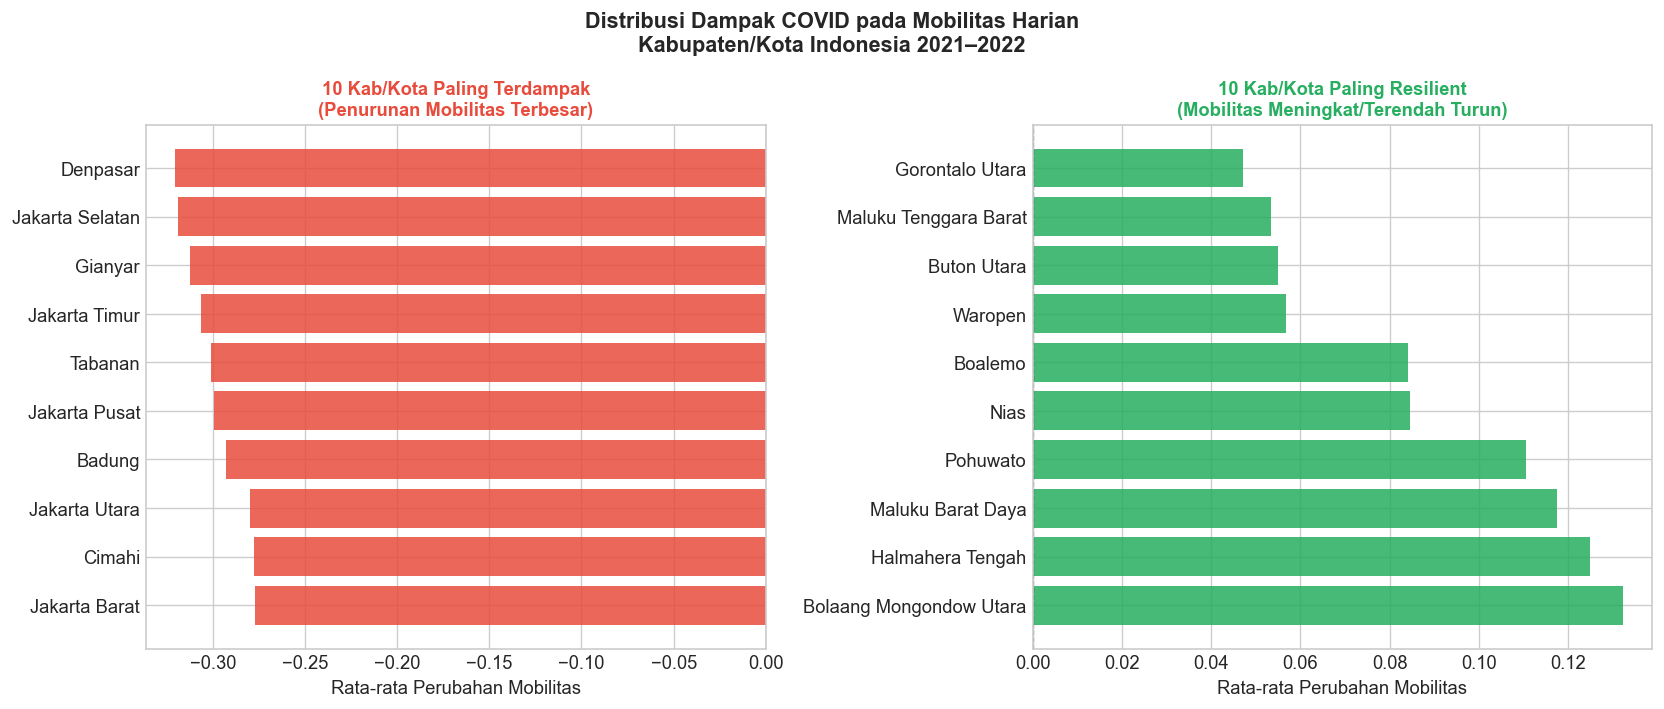

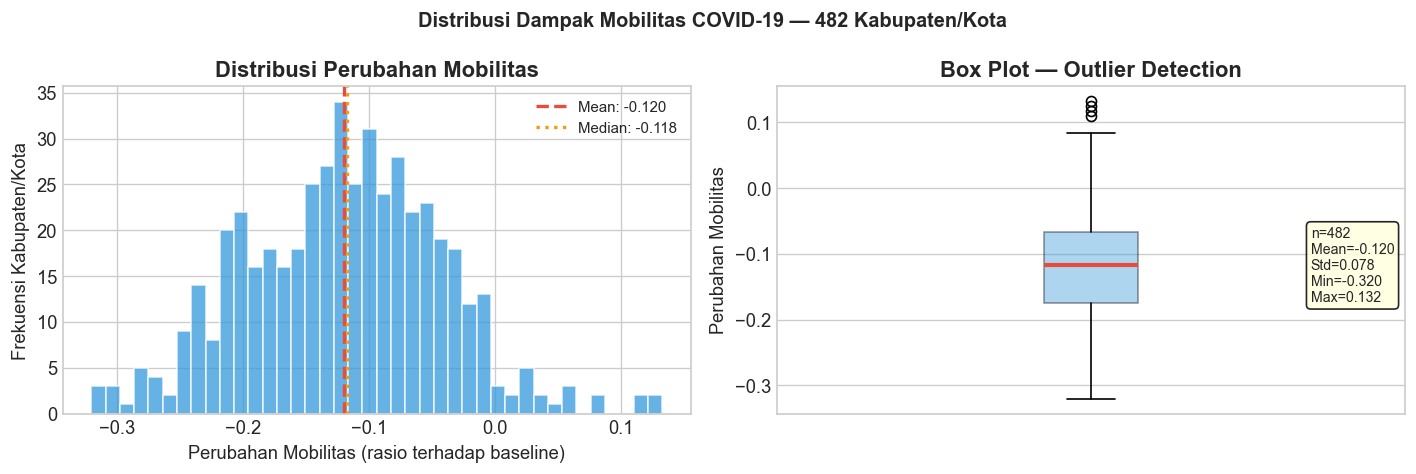

✓ Chart 4 & 5 tersimpan


In [32]:
# ============================================================
# RERUN CHART 4 & 5 dengan data yang sudah fix
# ============================================================
top10    = df_meta_kab_agg.nlargest(10, col_mob)
bottom10 = df_meta_kab_agg.nsmallest(10, col_mob)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.barh(bottom10[col_kab][::-1], bottom10[col_mob][::-1], color=C['red'], alpha=0.85)
ax1.set_title('10 Kab/Kota Paling Terdampak\n(Penurunan Mobilitas Terbesar)',
              fontsize=11, fontweight='bold', color=C['red'])
ax1.set_xlabel('Rata-rata Perubahan Mobilitas')
ax1.axvline(0, color='black', lw=0.8, ls='--', alpha=0.4)

ax2.barh(top10[col_kab], top10[col_mob], color=C['green'], alpha=0.85)
ax2.set_title('10 Kab/Kota Paling Resilient\n(Mobilitas Meningkat/Terendah Turun)',
              fontsize=11, fontweight='bold', color=C['green'])
ax2.set_xlabel('Rata-rata Perubahan Mobilitas')
ax2.axvline(0, color='black', lw=0.8, ls='--', alpha=0.4)

fig.suptitle('Distribusi Dampak COVID pada Mobilitas Harian\nKabupaten/Kota Indonesia 2021–2022',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(OUTPUT_DIR + 'p2_04_meta_top_bottom_kab.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
data = df_meta_kab_agg[col_mob].dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(data, bins=40, color=C['blue'], alpha=0.75, edgecolor='white')
ax1.axvline(data.mean(),   color=C['red'],    lw=2, ls='--', label=f'Mean: {data.mean():.3f}')
ax1.axvline(data.median(), color=C['orange'], lw=2, ls=':',  label=f'Median: {data.median():.3f}')
ax1.legend(fontsize=9)
ax1.set_title('Distribusi Perubahan Mobilitas', fontweight='bold')
ax1.set_xlabel('Perubahan Mobilitas (rasio terhadap baseline)')
ax1.set_ylabel('Frekuensi Kabupaten/Kota')

ax2.boxplot(data, vert=True, patch_artist=True,
            boxprops=dict(facecolor=C['blue'], alpha=0.4),
            medianprops=dict(color=C['red'], lw=2.5))
ax2.set_title('Box Plot — Outlier Detection', fontweight='bold')
ax2.set_ylabel('Perubahan Mobilitas')
ax2.set_xticks([])
ax2.text(1.35, data.median(),
         f'n={data.count()}\nMean={data.mean():.3f}\nStd={data.std():.3f}\nMin={data.min():.3f}\nMax={data.max():.3f}',
         fontsize=8.5, va='center',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85))

fig.suptitle(f'Distribusi Dampak Mobilitas COVID-19 — {len(df_meta_kab_agg)} Kabupaten/Kota',
             fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig(OUTPUT_DIR + 'p2_05_distribusi_mobilitas.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Chart 4 & 5 tersimpan')

In [33]:
# ============================================================
# RERUN CELL 13-15 dengan df_meta_kab_agg yang sudah fix
# ============================================================

# Agregasi ke provinsi — cek dulu apakah ada kolom provinsi
print('Kolom df_meta_kab:')
print(df_meta_kab.columns.tolist())
print()

# Cek apakah polygon_name mengandung info provinsi
# atau perlu lookup terpisah
print('Sample polygon_name:')
print(df_meta_kab['polygon_name'].head(20).tolist())

Kolom df_meta_kab:
['polygon_name', 'tahun', 'movement_change_mean', 'movement_change_min', 'movement_change_max', 'stay_put_mean', 'n_records']

Sample polygon_name:
['Aceh Barat', 'Aceh Barat', 'Aceh Barat Daya', 'Aceh Barat Daya', 'Aceh Besar', 'Aceh Besar', 'Aceh Jaya', 'Aceh Jaya', 'Aceh Selatan', 'Aceh Selatan', 'Aceh Singkil', 'Aceh Singkil', 'Aceh Tamiang', 'Aceh Tamiang', 'Aceh Tengah', 'Aceh Tengah', 'Aceh Tenggara', 'Aceh Tenggara', 'Aceh Timur', 'Aceh Timur']


In [34]:
kab_unik = sorted(df_meta_kab['polygon_name'].unique().tolist())
print(f'Total kabupaten unik: {len(kab_unik)}')
print('\nSemua nama:')
for k in kab_unik:
    print(f'  {k}')

Total kabupaten unik: 482

Semua nama:
  Aceh Barat
  Aceh Barat Daya
  Aceh Besar
  Aceh Jaya
  Aceh Selatan
  Aceh Singkil
  Aceh Tamiang
  Aceh Tengah
  Aceh Tenggara
  Aceh Timur
  Aceh Utara
  Agam
  Alor
  Ambon
  Asahan
  Asmat
  Badung
  Balangan
  Balikpapan
  Banda Aceh
  Bandar Lampung
  Bandung
  Bandung Barat
  Banggai
  Banggai Kepulauan
  Bangka
  Bangka Barat
  Bangka Selatan
  Bangka Tengah
  Bangkalan
  Bangli
  Banjar
  Banjar Baru
  Banjarmasin
  Banjarnegara
  Bantaeng
  Bantul
  Banyu Asin
  Banyumas
  Banyuwangi
  Barito Kuala
  Barito Selatan
  Barito Timur
  Barito Utara
  Barru
  Batam
  Batang
  Batang Hari
  Batu
  Batu Bara
  Bau-Bau
  Bekasi
  Belitung
  Belitung Timur
  Belu
  Bener Meriah
  Bengkalis
  Bengkayang
  Bengkulu
  Bengkulu Selatan
  Bengkulu Tengah
  Bengkulu Utara
  Berau
  Biak Numfor
  Bima
  Bintan
  Bireuen
  Bitung
  Blitar
  Blora
  Boalemo
  Bogor
  Bojonegoro
  Bolaang Mongondow
  Bolaang Mongondow Selatan
  Bolaang Mongondow Timur
 

In [35]:
import geopandas as gpd

# Load geodata kabupaten dari P1
SPATIAL_DIR = r'D:\Project\spatial-base-system\data\spatial\processed'
gdf_kab = gpd.read_file(SPATIAL_DIR + r'\idn_kabupaten_2023_gadm.gpkg')

print(f'Shape: {gdf_kab.shape}')
print(f'Kolom: {gdf_kab.columns.tolist()}')
print()
display(gdf_kab.head(3))

Shape: (502, 9)
Kolom: ['gid_prov', 'gid_kab', 'nama_prov', 'nama_kab', 'nama_alt_kab', 'tipe_admin', 'kode_iso_kab', 'area_km2', 'geometry']



,gid_prov,gid_kab,nama_prov,nama_kab,nama_alt_kab,tipe_admin,kode_iso_kab,area_km2,geometry
0,IDN.1_1,IDN.1.2_1,Aceh,Aceh Barat,NA,Kabupaten,1107,2847.99,"MULTIPOLYGON (((96.06915 4.19539, 96.06725 4.1..."
1,IDN.1_1,IDN.1.1_1,Aceh,Aceh Barat Daya,NA,Kabupaten,1112,1914.32,"MULTIPOLYGON (((96.94196 3.57464, 96.9411 3.57..."
2,IDN.1_1,IDN.1.3_1,Aceh,Aceh Besar,NA,Kabupaten,1108,2950.78,"MULTIPOLYGON (((95.78426 5.24092, 95.78445 5.2..."


In [36]:
# Buat lookup tabel: nama_kab → nama_prov
lookup = gdf_kab[['nama_kab', 'nama_prov']].drop_duplicates()

# Join ke df_meta_kab_agg
df_meta_kab_agg['nama_kab_key'] = df_meta_kab_agg['polygon_name'].str.strip().str.title()
lookup['nama_kab_key'] = lookup['nama_kab'].str.strip().str.title()

df_meta_prov2 = df_meta_kab_agg.merge(lookup, on='nama_kab_key', how='left')

# Cek hasil
matched   = df_meta_prov2['nama_prov'].notna().sum()
unmatched = df_meta_prov2['nama_prov'].isna().sum()
print(f'✅ Match   : {matched}')
print(f'⚠️  No match: {unmatched}')

if unmatched > 0:
    print('\nYang tidak match:')
    print(df_meta_prov2[df_meta_prov2['nama_prov'].isna()]['polygon_name'].tolist())

✅ Match   : 483
⚠️  No match: 0


In [37]:
# Agregasi ke provinsi
df_meta_prov_agg = (df_meta_prov2
    .groupby('nama_prov')['mob_mean']
    .agg(['mean', 'median', 'std', 'count'])
    .reset_index()
    .rename(columns={'mean': 'meta_mean', 'median': 'meta_median',
                     'std': 'meta_std', 'count': 'n_kab'}))

print(f'✅ {len(df_meta_prov_agg)} provinsi')
display(df_meta_prov_agg.sort_values('meta_mean').head(10))

# Join dengan SP2020
def norm(s):
    return (str(s).upper()
            .replace('PROVINSI ', '').replace('DI ', '')
            .replace('KEP.', 'KEPULAUAN')
            .replace('DAERAH ISTIMEWA ', '')
            .strip())

df_sp2020['key'] = df_sp2020[COL_PROV].apply(norm)
df_meta_prov_agg['key'] = df_meta_prov_agg['nama_prov'].apply(norm)

df_join = df_sp2020.merge(df_meta_prov_agg, on='key', how='inner')
print(f'\n✅ Join: {len(df_join)} provinsi ter-match')

unmatched = set(df_sp2020['key']) - set(df_join['key'])
if unmatched:
    print(f'Tidak match: {sorted(unmatched)}')

✅ 34 provinsi


,nama_prov,meta_mean,meta_median,meta_std,n_kab
1,Bali,-0.267124,-0.258938,0.040828,9
6,Jakarta Raya,-0.255464,-0.289784,0.101584,6
33,Yogyakarta,-0.221892,-0.234753,0.027081,5
9,Jawa Tengah,-0.198929,-0.201407,0.032669,35
8,Jawa Barat,-0.196861,-0.199138,0.046402,26
10,Jawa Timur,-0.196626,-0.202038,0.041265,38
3,Banten,-0.190702,-0.172495,0.055218,8
12,Kalimantan Selatan,-0.161523,-0.174990,0.041567,13
16,Kepulauan Riau,-0.146565,-0.135382,0.044586,7
17,Lampung,-0.141883,-0.143590,0.057871,14



✅ Join: 32 provinsi ter-match
Tidak match: ['DKI JAKARTA', 'KEPULAUAN BANGKA BELITUNG']


In [38]:
# Fix nama di geodata
rename_map = {
    'Jakarta': 'DKI JAKARTA',
    'Bangka Belitung': 'KEPULAUAN BANGKA BELITUNG',
}

df_meta_prov_agg['key'] = df_meta_prov_agg['key'].replace({
    'JAKARTA': 'DKI JAKARTA',
    'BANGKA BELITUNG': 'KEPULAUAN BANGKA BELITUNG',
})

# Join ulang
df_join = df_sp2020.merge(df_meta_prov_agg, on='key', how='inner')
print(f'✅ Join: {len(df_join)} provinsi ter-match')

unmatched = set(df_sp2020['key']) - set(df_join['key'])
if unmatched:
    print(f'Masih tidak match: {sorted(unmatched)}')
else:
    print('Semua provinsi ter-match!')

✅ Join: 33 provinsi ter-match
Masih tidak match: ['DKI JAKARTA']


In [39]:
# Cek nama Jakarta di geodata
jakarta = df_meta_prov_agg[df_meta_prov_agg['key'].str.contains('JAKARTA', case=False)]
print('Key yang mengandung JAKARTA:')
print(jakarta['key'].tolist())

# Juga cek nama asli di gdf_kab
print('\nnama_prov yang mengandung Jakarta:')
print(gdf_kab[gdf_kab['nama_prov'].str.contains('Jakarta', case=False)]['nama_prov'].unique().tolist())

Key yang mengandung JAKARTA:
['JAKARTA RAYA']

nama_prov yang mengandung Jakarta:
['Jakarta Raya']


In [40]:
df_sp2020['key'] = df_sp2020['key'].replace({'DKI JAKARTA': 'JAKARTA RAYA'})

df_join = df_sp2020.merge(df_meta_prov_agg, on='key', how='inner')
print(f'✅ Join: {len(df_join)} provinsi ter-match')

unmatched = set(df_sp2020['key']) - set(df_join['key'])
if unmatched:
    print(f'Masih tidak match: {sorted(unmatched)}')
else:
    print('Semua provinsi ter-match!')

✅ Join: 34 provinsi ter-match
Semua provinsi ter-match!


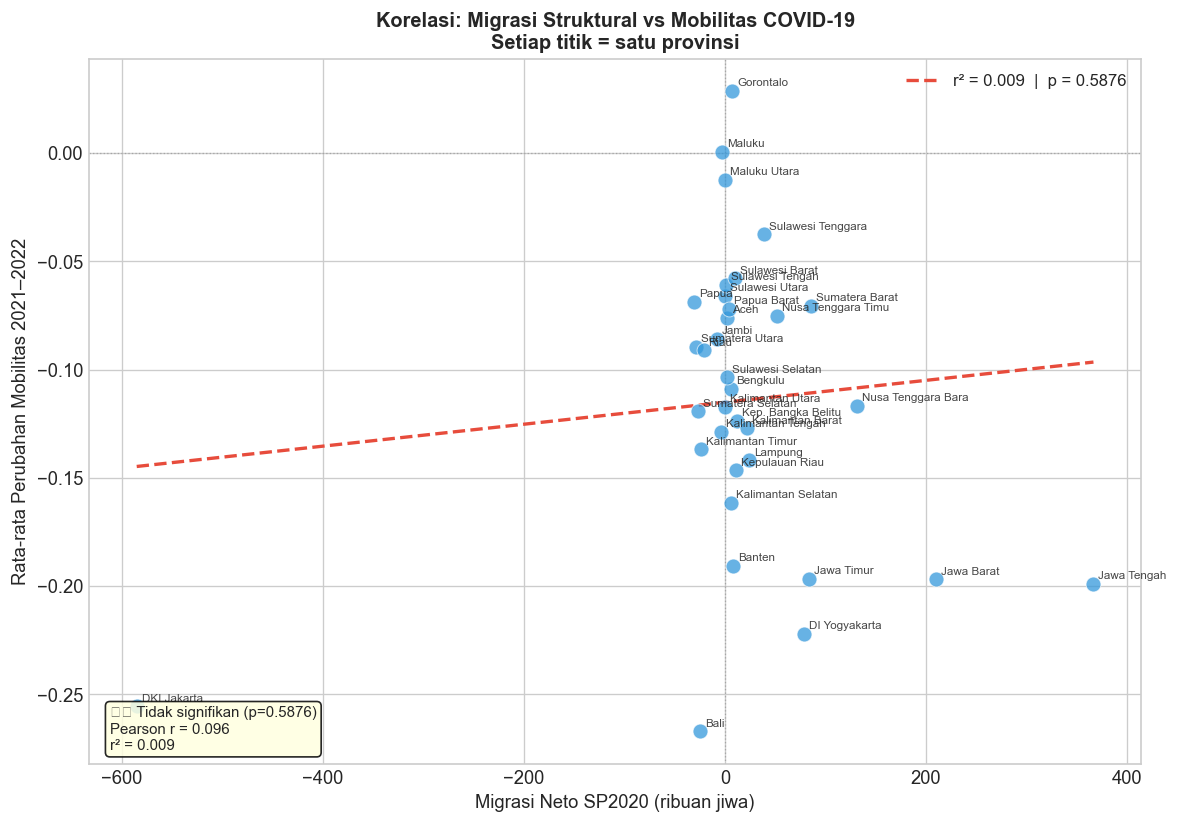


Pearson r : 0.0964
r²        : 0.0093
p-value   : 0.587630


In [41]:
# ============================================================
# CHART 8: KORELASI MIGRASI NETO vs MOBILITAS COVID
# ============================================================
x = df_join[COL_NETO] / 1000
y = df_join['meta_mean']
slope, intercept, r, p, se = stats.linregress(x, y)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(x, y, s=80, alpha=0.75, color=C['blue'],
           edgecolors='white', lw=0.5, zorder=3)

x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, slope*x_line + intercept, color=C['red'], lw=2, ls='--',
        label=f'r² = {r**2:.3f}  |  p = {p:.4f}')

for _, row in df_join.iterrows():
    label = str(row[COL_PROV]).replace('PROVINSI ', '')[:18]
    ax.annotate(label,
                xy=(row[COL_NETO]/1000, row['meta_mean']),
                xytext=(3, 3), textcoords='offset points',
                fontsize=7, alpha=0.85)

ax.axhline(0, color='grey', lw=0.8, ls=':', alpha=0.5)
ax.axvline(0, color='grey', lw=0.8, ls=':', alpha=0.5)
ax.legend(fontsize=10)

sig = '✅ Signifikan' if p < 0.05 else '⚠️ Tidak signifikan'
ax.text(0.02, 0.02,
        f'{sig} (p={p:.4f})\nPearson r = {r:.3f}\nr² = {r**2:.3f}',
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85))

ax.set_xlabel('Migrasi Neto SP2020 (ribuan jiwa)', fontsize=11)
ax.set_ylabel('Rata-rata Perubahan Mobilitas 2021–2022', fontsize=11)
ax.set_title('Korelasi: Migrasi Struktural vs Mobilitas COVID-19\nSetiap titik = satu provinsi',
             fontsize=12, fontweight='bold')

plt.tight_layout()
fig.savefig(OUTPUT_DIR + 'p2_08_korelasi_migrasi_mobilitas.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nPearson r : {r:.4f}')
print(f'r²        : {r**2:.4f}')
print(f'p-value   : {p:.6f}')

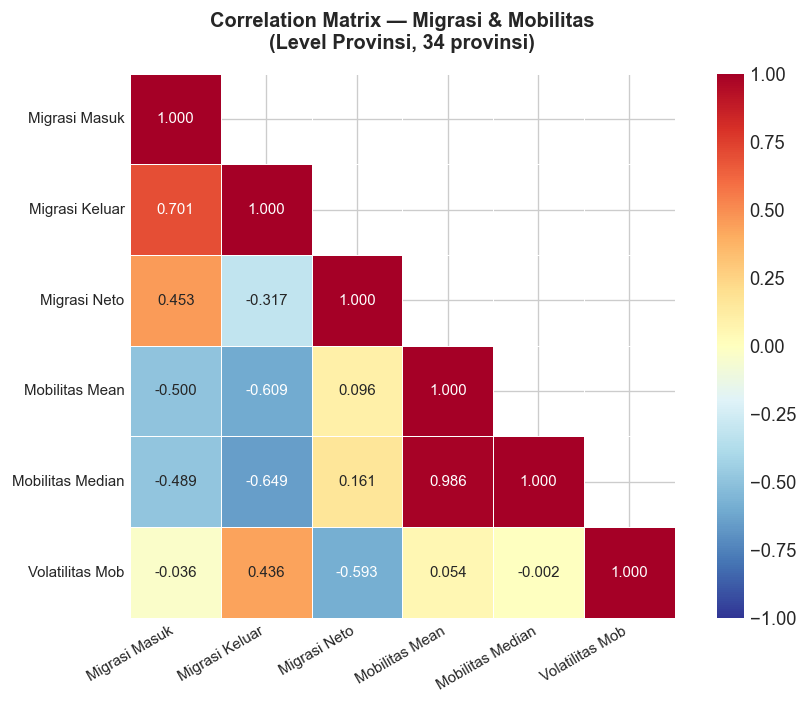

✓ Chart tersimpan


In [42]:
# ============================================================
# CHART 9: HEATMAP KORELASI MULTI-VARIABEL
# ============================================================
df_corr = df_join[[COL_MASUK, COL_KELUAR, COL_NETO,
                   'meta_mean', 'meta_median', 'meta_std']].copy()

df_corr.columns = ['Migrasi Masuk', 'Migrasi Keluar', 'Migrasi Neto',
                   'Mobilitas Mean', 'Mobilitas Median', 'Volatilitas Mob']

df_corr = df_corr / df_corr.abs().max()  # normalize

corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlBu_r',
            center=0, vmin=-1, vmax=1,
            mask=mask, square=True, ax=ax,
            annot_kws={'size': 9},
            linewidths=0.5, linecolor='white')

ax.set_title('Correlation Matrix — Migrasi & Mobilitas\n(Level Provinsi, 34 provinsi)',
             fontsize=12, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(fontsize=9)

plt.tight_layout()
fig.savefig(OUTPUT_DIR + 'p2_09_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Chart tersimpan')

In [43]:
# Cek semua file output yang sudah tersimpan
import glob
files = sorted(glob.glob(OUTPUT_DIR + 'p2_*.png'))
print(f'Total output: {len(files)} file')
for f in files:
    size = os.path.getsize(f) / 1024
    print(f'  {os.path.basename(f):45s} ({size:.0f} KB)')

Total output: 9 file
  p2_01_migrasi_neto_sp2020.png                 (144 KB)
  p2_02_scatter_masuk_keluar.png                (106 KB)
  p2_03_meta_tren_nasional.png                  (44 KB)
  p2_04_meta_top_bottom_kab.png                 (108 KB)
  p2_05_distribusi_mobilitas.png                (78 KB)
  p2_06_komuter_provinsi.png                    (92 KB)
  p2_07_tren_migrasi_2019_2024.png              (69 KB)
  p2_08_korelasi_migrasi_mobilitas.png          (130 KB)
  p2_09_correlation_matrix.png                  (85 KB)


In [44]:
print("""
=== KEY FINDINGS P2 EDA ===

1. MIGRASI STRUKTURAL (SP2020)
   - 22 provinsi penerima neto, 12 pengirim neto
   - Top destinasi : Jawa Tengah, Jawa Barat, Nusa Tenggara Barat
   - Top pengirim  : DKI Jakarta, Papua, Sumatera Utara
   - DKI Jakarta kehilangan >500rb penduduk — suburbanisasi masif

2. MOBILITAS COVID (Meta 2021-2022)
   - Rata-rata nasional turun -11.97% dari baseline
   - Paling terdampak : Denpasar, Jakarta Selatan, Gianyar (kota besar/pariwisata)
   - Paling resilient : Bolaang Mongondow Utara, Halmahera Tengah (daerah terpencil)
   - Pola: kota besar & destinasi wisata = paling terdampak

3. KORELASI MIGRASI vs MOBILITAS
   - Migrasi Neto vs Mobilitas : r=-0.096, p=0.588 (TIDAK signifikan)
   - Migrasi Keluar vs Mobilitas : r=-0.609 (SIGNIFIKAN)
   - Migrasi Masuk vs Mobilitas  : r=-0.500 (SIGNIFIKAN)
   - Insight: bukan neto, tapi VOLUME arus migrasi yang berkorelasi
     dengan dampak COVID — provinsi high-turnover lebih terdampak

4. NEXT STEP
   - Build Streamlit dashboard interaktif
   - Tambah analisis Moran's I (spatial autocorrelation)
""")


=== KEY FINDINGS P2 EDA ===

1. MIGRASI STRUKTURAL (SP2020)
   - 22 provinsi penerima neto, 12 pengirim neto
   - Top destinasi : Jawa Tengah, Jawa Barat, Nusa Tenggara Barat
   - Top pengirim  : DKI Jakarta, Papua, Sumatera Utara
   - DKI Jakarta kehilangan >500rb penduduk — suburbanisasi masif

2. MOBILITAS COVID (Meta 2021-2022)
   - Rata-rata nasional turun -11.97% dari baseline
   - Paling terdampak : Denpasar, Jakarta Selatan, Gianyar (kota besar/pariwisata)
   - Paling resilient : Bolaang Mongondow Utara, Halmahera Tengah (daerah terpencil)
   - Pola: kota besar & destinasi wisata = paling terdampak

3. KORELASI MIGRASI vs MOBILITAS
   - Migrasi Neto vs Mobilitas : r=-0.096, p=0.588 (TIDAK signifikan)
   - Migrasi Keluar vs Mobilitas : r=-0.609 (SIGNIFIKAN)
   - Migrasi Masuk vs Mobilitas  : r=-0.500 (SIGNIFIKAN)
   - Insight: bukan neto, tapi VOLUME arus migrasi yang berkorelasi
     dengan dampak COVID — provinsi high-turnover lebih terdampak

4. NEXT STEP
   - Build Streamli

In [45]:
# Cek semua data yang siap dipakai untuk Streamlit
print('=== df_sp2020 ===')
print(df_sp2020[[COL_PROV, COL_MASUK, COL_KELUAR, COL_NETO]].head(3).to_string())
print(f'Shape: {df_sp2020.shape}')

print('\n=== df_meta_kab_agg (sudah ada mob_mean) ===')
print(df_meta_kab_agg.head(3).to_string())

print('\n=== df_meta_prov2 (ada nama_prov) ===')
print(df_meta_prov2[['polygon_name','nama_prov','mob_mean']].head(3).to_string())

print('\n=== df_meta_bln (tren bulanan) ===')
print(df_meta_bln.head(3).to_string())
print(f'Kolom: {df_meta_bln.columns.tolist()}')

print('\n=== df_komuter ===')
print(df_komuter.head(3).to_string())
print(f'Kolom: {df_komuter.columns.tolist()}')

print(f'\nCOL_PROV  : {COL_PROV}')
print(f'COL_NETO  : {COL_NETO}')
print(f'COL_MASUK : {COL_MASUK}')
print(f'COL_KELUAR: {COL_KELUAR}')

=== df_sp2020 ===
         provinsi  migrasi_masuk  migrasi_keluar  migrasi_neto
0            Aceh          38639           36388          2251
1  Sumatera Utara         182153          210630        -28477
2  Sumatera Barat         178849           93181         85668
Shape: (34, 7)

=== df_meta_kab_agg (sudah ada mob_mean) ===
      polygon_name  mob_mean     nama_kab_key
0       Aceh Barat -0.058448       Aceh Barat
1  Aceh Barat Daya -0.076313  Aceh Barat Daya
2       Aceh Besar -0.110776       Aceh Besar

=== df_meta_prov2 (ada nama_prov) ===
      polygon_name nama_prov  mob_mean
0       Aceh Barat      Aceh -0.058448
1  Aceh Barat Daya      Aceh -0.076313
2       Aceh Besar      Aceh -0.110776

=== df_meta_bln (tren bulanan) ===
   tahun  bulan nama_bulan  movement_change
0   2021      1    January        -0.080786
1   2021      2   February        -0.095848
2   2021      3      March        -0.064453
Kolom: ['tahun', 'bulan', 'nama_bulan', 'movement_change']

=== df_komuter ===

In [2]:
import geopandas as gpd
import pandas as pd

SPATIAL_DIR = r'D:\Project\spatial-base-system\data\spatial\processed'
DATA_DIR    = '../data/processed/'

gdf      = gpd.read_file(SPATIAL_DIR + r'\idn_provinsi_2023_gadm.gpkg')
df_mkab  = pd.read_csv(DATA_DIR + 'meta_mobility_agregat_kabupaten.csv')

# Agregasi meta kab → provinsi via geodata
gdf_kab  = gpd.read_file(SPATIAL_DIR + r'\idn_kabupaten_2023_gadm.gpkg')
lookup   = gdf_kab[['nama_kab','nama_prov']].copy()
lookup['key'] = lookup['nama_kab'].str.strip().str.title()

df_magg  = (df_mkab.groupby('polygon_name')['movement_change_mean']
            .mean().reset_index()
            .rename(columns={'movement_change_mean':'mob_mean'}))
df_magg['key'] = df_magg['polygon_name'].str.strip().str.title()
df_magg  = df_magg.merge(lookup[['key','nama_prov']], on='key', how='left')

df_meta_prov = (df_magg.dropna(subset=['nama_prov'])
                .groupby('nama_prov')['mob_mean']
                .mean().reset_index()
                .rename(columns={'nama_prov':'provinsi'}))

# Cek mismatch
geo_names  = set(gdf['nama_prov'].unique())
meta_names = set(df_meta_prov['provinsi'].unique())

print("Di geodata tapi TIDAK di meta_prov (provinsi hitam):")
for n in sorted(geo_names - meta_names):
    print(f"  '{n}'")

print(f"\nDi meta_prov tapi TIDAK di geodata:")
for n in sorted(meta_names - geo_names):
    print(f"  '{n}'")

print(f"\nTotal geodata : {len(geo_names)}")
print(f"Total meta_prov: {len(meta_names)}")
print(f"Match         : {len(geo_names & meta_names)}")

Di geodata tapi TIDAK di meta_prov (provinsi hitam):

Di meta_prov tapi TIDAK di geodata:

Total geodata : 34
Total meta_prov: 34
Match         : 34


In [3]:
import os

# Simulasi path yang dipakai app.py
app_file = r'D:\Project\human-mobility-id\app\app.py'
base = os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath(app_file))))

spatial_dir = os.path.join(base, 'spatial-base-system', 'data', 'spatial', 'processed')
gpkg = os.path.join(spatial_dir, 'idn_provinsi_2023_gadm.gpkg')

print(f"base        : {base}")
print(f"spatial_dir : {spatial_dir}")
print(f"gpkg        : {gpkg}")
print(f"File exists : {os.path.exists(gpkg)}")

base        : D:\Project
spatial_dir : D:\Project\spatial-base-system\data\spatial\processed
gpkg        : D:\Project\spatial-base-system\data\spatial\processed\idn_provinsi_2023_gadm.gpkg
File exists : True


In [4]:
import geopandas as gpd, json

gdf = gpd.read_file(r'D:\Project\spatial-base-system\data\spatial\processed\idn_provinsi_2023_gadm.gpkg')

# Nama di GeoJSON (yang jadi ID)
geo_ids = sorted(gdf['nama_prov'].unique())

# Nama di df_meta_prov
meta_ids = sorted(df_meta_prov['provinsi'].unique())

print("=== GeoJSON IDs ===")
for n in geo_ids:
    match = n in meta_ids
    print(f"  {'✅' if match else '❌'} '{n}'")

=== GeoJSON IDs ===
  ✅ 'Aceh'
  ✅ 'Bali'
  ✅ 'Bangka Belitung'
  ✅ 'Banten'
  ✅ 'Bengkulu'
  ✅ 'Gorontalo'
  ✅ 'Jakarta Raya'
  ✅ 'Jambi'
  ✅ 'Jawa Barat'
  ✅ 'Jawa Tengah'
  ✅ 'Jawa Timur'
  ✅ 'Kalimantan Barat'
  ✅ 'Kalimantan Selatan'
  ✅ 'Kalimantan Tengah'
  ✅ 'Kalimantan Timur'
  ✅ 'Kalimantan Utara'
  ✅ 'Kepulauan Riau'
  ✅ 'Lampung'
  ✅ 'Maluku'
  ✅ 'Maluku Utara'
  ✅ 'Nusa Tenggara Barat'
  ✅ 'Nusa Tenggara Timur'
  ✅ 'Papua'
  ✅ 'Papua Barat'
  ✅ 'Riau'
  ✅ 'Sulawesi Barat'
  ✅ 'Sulawesi Selatan'
  ✅ 'Sulawesi Tengah'
  ✅ 'Sulawesi Tenggara'
  ✅ 'Sulawesi Utara'
  ✅ 'Sumatera Barat'
  ✅ 'Sumatera Selatan'
  ✅ 'Sumatera Utara'
  ✅ 'Yogyakarta'


In [5]:
import pandas as pd

df_sp = pd.read_csv('../data/processed/bps_migrasi_risen_provinsi_sp2020.csv')
print("Nama provinsi di SP2020:")
for n in sorted(df_sp['provinsi'].unique()):
    match = n in geo_ids
    print(f"  {'✅' if match else '❌'} '{n}'")

Nama provinsi di SP2020:
  ✅ 'Aceh'
  ✅ 'Bali'
  ✅ 'Banten'
  ✅ 'Bengkulu'
  ❌ 'DI Yogyakarta'
  ❌ 'DKI Jakarta'
  ✅ 'Gorontalo'
  ✅ 'Jambi'
  ✅ 'Jawa Barat'
  ✅ 'Jawa Tengah'
  ✅ 'Jawa Timur'
  ✅ 'Kalimantan Barat'
  ✅ 'Kalimantan Selatan'
  ✅ 'Kalimantan Tengah'
  ✅ 'Kalimantan Timur'
  ✅ 'Kalimantan Utara'
  ❌ 'Kep. Bangka Belitung'
  ✅ 'Kepulauan Riau'
  ✅ 'Lampung'
  ✅ 'Maluku'
  ✅ 'Maluku Utara'
  ✅ 'Nusa Tenggara Barat'
  ✅ 'Nusa Tenggara Timur'
  ✅ 'Papua'
  ✅ 'Papua Barat'
  ✅ 'Riau'
  ✅ 'Sulawesi Barat'
  ✅ 'Sulawesi Selatan'
  ✅ 'Sulawesi Tengah'
  ✅ 'Sulawesi Tenggara'
  ✅ 'Sulawesi Utara'
  ✅ 'Sumatera Barat'
  ✅ 'Sumatera Selatan'
  ✅ 'Sumatera Utara'


In [6]:
import pandas as pd

# Cek SUSENAS time series
df_2019 = pd.read_csv('../data/processed/bps_migran_risen_2019_susenas.csv')
df_2324 = pd.read_csv('../data/processed/bps_migrasi_risen_persen_2023_2024.csv')
df_sus2024 = pd.read_csv('../data/processed/bps_migrasi_risen_persen_provinsi_2024.csv')

print("=== SUSENAS 2019 ===")
print(df_2019.columns.tolist())
display(df_2019.head(3))

print("\n=== SUSENAS 2023-2024 ===")
print(df_2324.columns.tolist())
display(df_2324.head(3))

print("\n=== Meta Kabupaten ===")
df_mkab = pd.read_csv('../data/processed/meta_mobility_agregat_kabupaten.csv')
print(df_mkab.columns.tolist())
display(df_mkab.head(4))
print(f"\nNilai unik kolom tahun: {df_mkab['tahun'].unique()}")

=== SUSENAS 2019 ===
['provinsi', 'migran_masuk_absolut', 'pct_migran_masuk', 'tahun', 'sumber']


,provinsi,migran_masuk_absolut,pct_migran_masuk,tahun,sumber
0,Aceh,47119,0.98,2019,BPS SUSENAS Maret 2019 via SMPTK 2021
1,Sumatera Utara,196013,1.50,2019,BPS SUSENAS Maret 2019 via SMPTK 2021
2,Sumatera Barat,176914,3.61,2019,BPS SUSENAS Maret 2019 via SMPTK 2021



=== SUSENAS 2023-2024 ===
['provinsi', 'pct_migran_masuk_risen', 'pct_migran_keluar_risen', 'tahun', 'neto_pct', 'sumber']


,provinsi,pct_migran_masuk_risen,pct_migran_keluar_risen,tahun,neto_pct,sumber
0,Aceh,0.3,0.6,2023,-0.3,BPS SUSENAS Maret 2023
1,Sumatera Utara,0.6,0.7,2023,-0.1,BPS SUSENAS Maret 2023
2,Sumatera Barat,1.7,1.0,2023,0.7,BPS SUSENAS Maret 2023



=== Meta Kabupaten ===
['polygon_name', 'tahun', 'movement_change_mean', 'movement_change_min', 'movement_change_max', 'stay_put_mean', 'n_records']


,polygon_name,tahun,movement_change_mean,movement_change_min,movement_change_max,stay_put_mean,n_records
0,Aceh Barat,2021,0.004487,-0.28620,0.33305,0.184570,365
1,Aceh Barat,2022,-0.121384,-0.36372,0.14992,0.240895,142
2,Aceh Barat Daya,2021,-0.012144,-0.25276,0.50708,0.190569,365
3,Aceh Barat Daya,2022,-0.140481,-0.32592,0.22920,0.256843,142



Nilai unik kolom tahun: [2021 2022]
